In [1]:
import polars as pl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

Analisar sequestro
1. Comportamento temporal (ano)
2. Qual região teve mais sequestro?


In [3]:
# OBTER DADOS
try:
    dados = pd.read_csv(
        '03.BaseDPEvolucaoMensalCisp.csv',
        sep=';', encoding='iso-8859-1')
    dp = pd.read_csv('08.DP.csv', sep=',', 
                     encoding='utf-8')
    # juntar com codDP
    df_comDP = dados.merge(dp, left_on='cisp',
                           right_on='codDP', how='left')
    df_sequestro = df_comDP[['cisp', 'nome', 'sequestro', 
                             'regiao', 'ano']]
    
except Exception as e:
    print(f'Erro ao obter dados: {e}')
    

In [4]:
# ANALISE
try:
    df_sequestro_ano = \
    df_sequestro.groupby('ano')['sequestro'].sum().reset_index()
    
    # print(df_sequestro_ano)
    df_sequestro_regiao = \
    df_sequestro.groupby('regiao')['sequestro']. \
    sum().reset_index().sort_values(by='sequestro', 
                                    ascending=False)

except Exception as e:
    print(f'Erro ao analisar os dados: {e}')

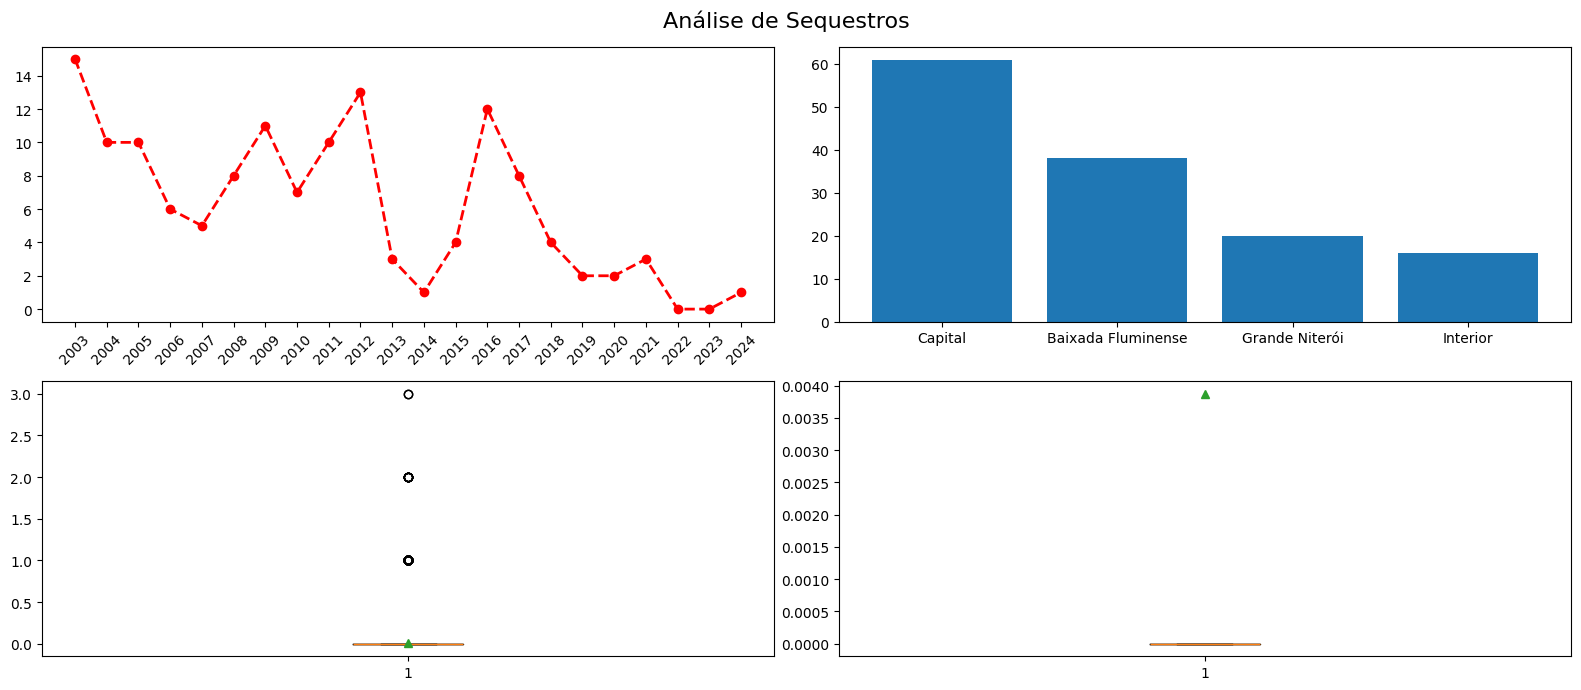

In [5]:
# VISUALIZAÇÃO
try:
    # criação de uma area para graficos (2, 2) -> 4 espaços
    plt.subplots(2, 2, figsize=(16, 7))
    plt.suptitle('Análise de Sequestros', fontsize=16)

    # subplot -> (x, y, z) -> x e y repentem valor do subplots
    # z é a posição que o grafico vai ficar no subplots

    # primeiro grafico -> por ano (linha)
    plt.subplot(2, 2, 1)
    plt.plot(df_sequestro_ano['ano'].astype(str), 
            df_sequestro_ano['sequestro'], 
            marker='o', color='red', linestyle='--',
            linewidth=2)
    plt.xticks(rotation=45)

    # segundo grafico -> por regiao (barra)
    plt.subplot(2, 2, 2)
    plt.bar(df_sequestro_regiao['regiao'], 
            df_sequestro_regiao['sequestro'])
    
    # terceiro grafico -> boxplot
    plt.subplot(2, 2, 3)
    plt.boxplot(df_sequestro['sequestro'], showmeans=True,
                showfliers=True)
    
    # quarto quadrante -> boxplot sem outliers
    plt.subplot(2, 2, 4)
    plt.boxplot(df_sequestro['sequestro'], showmeans=True,
                showfliers=False)



    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Erro na vizualização de dados: {e}')